# Оценка частоты дыхания (RR) по видео в условиях слабого освещения

**Отчёт по заданию** · Технологии интеллектуальных систем (ИТМО) · 2026

**Автор:** _______________  ·  gy@agmo.cat

Задание основано на презентации *«Vital Signs estimation through video analysis»* (Walaa Othman).
Мы воспроизводим метод оценки частоты дыхания со **слайда 4** (skeletonization + оптический поток)
на собственном видео, снятом в слабом освещении, и анализируем, где метод даёт сбой.

---
### Постановка задачи (слайд 24)
1. Выбрать сложную среду и определить конкретные источники шума.
2. Предложить архитектуру системы для **одного** витального показателя (схема, без кода) и обосновать выбор.
3. Записать видео 2–3 мин с ground truth частоты дыхания (посчитать вдохи вручную).
4. Найти ключевые точки (keypoints) современным методом.
5. Оптическим потоком (NN) определить смещение, построить 1D-сигнал RR по методу слайда 4
   и вручную отметить, где и почему метод даёт сбой.

**Наш выбор:** показатель — **частота дыхания (RR)**; среда — **слабое освещение**.

## 1. Сценарий и источники шума

### Суть метода вкратце

Мы измеряем частоту дыхания (RR) прямо по видео, без датчиков на теле. Идея простая:
когда человек дышит, грудь чуть поднимается и опускается. Мы находим точку на груди и следим,
как она смещается вверх-вниз от кадра к кадру. Получается волнистый сигнал; считаем его пики
(каждый пик - один вдох) и переводим в число вдохов в минуту.

Главное: мы смотрим на `движение` точки, а не на `цвет` или `яркость` кожи (как это делают
пульсовые методы rPPG). Поэтому освещение почти не мешает - метод работает даже в темноте.
Это и есть причина выбрать его под наш сценарий со слабым светом.

### Сценарий

Человек сидит в тёмной комнате при слабом красноватом свете (средняя яркость кадра около 48 из 255).
Фронтальная камера смартфона видит лицо и торс.

### Что мешает (источники шума)

| Источник шума | Как портит сигнал |
|---|---|
| Мало света - высокий ISO камеры | Зернистость картинки, из-за неё ложные мелкие смещения |
| Мерцание света (лампы 50 Гц, экран) | Медленный дрейф и лишние колебания яркости |
| Тени и низкий контраст на груди | Точку груди находит хуже, она `плавает` |
| Непроизвольные движения, смена позы | Медленные качания корпуса поверх дыхания |
| Смаз при длинной выдержке в темноте | Размытые границы, из-за них ошибки слежения |
| Настройка и остановка записи | Крупные движения рук/корпуса - явные сбои |

#### Noise sources (English)

| Noise source | How it corrupts the signal |
|---|---|
| Low light - high camera ISO | Image grain causes false small displacements |
| Light flicker (50 Hz lamps, screen) | Slow drift and extra brightness fluctuations |
| Shadows and low contrast on the chest | Chest point is detected worse, it `drifts` |
| Involuntary movements, posture change | Slow body sway on top of the breathing wave |
| Motion blur (long exposure in the dark) | Blurred edges cause tracking errors |
| Setup and stopping the recording | Large hand/body motion - clear failures |

**Вывод:** свет методу почти не мешает (меряем движение, а не яркость), а вот лишние движения
тела - мешают. Поэтому снимаем сидя и стараемся не двигаться.

## 2. Архитектура системы для оценки RR

Ниже - весь путь от видео до числа `RR`. Сначала общая схема, потом разбор каждого блока:
что подаём на вход, что делаем, что получаем на выходе. Почти всё повторяет метод со слайда 4;
единственное наше добавление под слабый свет - блок предобработки в начале.

### Схема (сверху вниз)

```
Видео (кадры с камеры)
        |
Предобработка: убрать шум + поднять контраст   <- наше добавление под слабый свет
        |
Найти точку груди (MediaPipe)
        |
Оптический поток RAFT: куда сместилась точка
        |
Проекция: берём движение вверх-вниз (вертикаль)
        |
Фильтр: убрать дрейф, оставить частоту дыхания
        |
Счёт пиков -> RR (вдохов в минуту)
```

### Что делает каждый блок

**1. Видео.** Вход всей системы - кадры с камеры (30 штук в секунду), на них виден торс человека.

**2. Предобработка (под слабый свет).** Убираем зернистость (денойзинг) и вытягиваем контраст
(CLAHE - выравнивание яркости). Зачем: в темноте картинка шумная и тусклая, после чистки точку
груди и её движение видно лучше. На выходе - те же кадры, но чище.

**3. Поиск точки груди (keypoints).** Нейросеть MediaPipe находит опорные точки тела (плечи, бёдра),
и мы вычисляем из них точку на груди. Важно: этот блок сам дыхание не меряет - он только говорит,
`за какой областью следить`. На выходе - координаты точки груди на каждом кадре.

**4. Оптический поток (RAFT).** Сравниваем два соседних кадра и считаем, куда сдвинулись пиксели.
Берём среднее смещение в маленьком окне вокруг точки груди. Это и есть измерение движения груди.
На выходе - смещение точки (влево-вправо `dx` и вверх-вниз `dy`) на каждом кадре.

**5. Проекция на оси.** Из смещения берём только вертикаль `dy` (вверх-вниз) - дыхание двигает грудь
именно так. Горизонталь `dx` оставляем отдельно как индикатор посторонних движений. На выходе -
один одномерный сигнал: вертикальное смещение груди во времени.

**6. Обработка сигнала (фильтр).** Сначала убираем медленный сползающий тренд (detrend), потом
полосовым фильтром оставляем только частоты, похожие на дыхание. Зачем: выкинуть шум и медленное
качание, оставить чистую дыхательную волну. На выходе - гладкий волнистый сигнал дыхания.

**7. Счёт пиков -> RR.** Находим пики сигнала (каждый подъём груди - это вдох), делим их число на
длину записи и умножаем на 60. На выходе - частота дыхания в вдохах за минуту.

### Почему выбрали именно этот метод

1. **Не боится темноты.** Меряем движение точки, а не яркость кожи. Пульсовые методы (rPPG) в темноте
   ломаются, а наш - нет. Это главный аргумент под сценарий со слабым светом.
2. **Точный.** По слайдам 9 и 23 этот подход даёт лучшую точность RR (ошибка MAE около 4).
3. **Понятный и без обучения.** Простая цепочка `поток -> фильтр -> пики`, не нужен размеченный
   датасет и тяжёлое обучение сети. Легко объяснить и проверить.
4. **Честная граница.** Слабое место метода (слайд 7) - движение тела. Мы это учитываем: снимаем сидя
   и неподвижно, поэтому метод работает в своей сильной зоне.

## 3. Видео и ground truth RR

**Видео.** Сняли сами: тёмная комната, слабый красноватый свет, человек сидит, виден торс.
30 кадров в секунду, вертикальное 1080x1920. Исходник `data/prod_video.mp4` длиной 2 мин 22 с
записан с запасом. Крупные движения были только когда тянулись к телефону в начале и в конце,
поэтому ролик обрезали до спокойного куска (4-139 с) -> `data/prod_video_trim.mp4` (2 мин 15 с).
Его и разбираем.

**Ground truth (эталон).** Это `правильный ответ`, с которым потом сравниваем результат метода.
Считается просто: человек сам считает свои вдохи во время записи. У нас вышло 33 вдоха за 135 с -
это и есть эталон (`RR_GT`). В конце сравним его с оценкой метода и посчитаем ошибку.

Кодом этот пункт объяснять не нужно - тут только описание. Ниже идёт технический блок настройки,
он нужен уже для пунктов 4-5.

### Технический блок: настройка и загрузка видео

Здесь только подготовка: подключаем библиотеки, задаём параметры (какое видео, размер кадра, эталон
`RR_GT`, кэш) и загружаем кадры видео в память. Для понимания сути метода этот код не важен - он нужен,
чтобы дальше (пункты 4-5) было с чем работать.

In [1]:
import os, cv2, numpy as np, torch
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt, find_peaks
import mediapipe as mp

VIDEO_PATH     = "data/prod_video_trim.mp4"  # обрезанное своё видео (тест был data/test_video.mp4)
RESIZE_WIDTH   = 384      # ширина кадра для RAFT (даунскейл; делится на 8). 384 — экономно для 4 ГБ VRAM
RAFT_MODEL     = "small"  # 'small' — экономит VRAM. 'large' — точнее, тяжелее
ROI_HALF       = 12       # полуразмер окна (px) для усреднения потока вокруг точки груди
RR_GT          = 33/135.4*60  # ground truth: 33 вдоха за 135.4 c (ручной счёт)
ANALYSIS_START = None     # с: начало окна расчёта RR. None = с 0 (видео уже обрезано)
ANALYSIS_END   = None     # с: конец окна. None = до конца клипа

# Кэш тяжёлых шагов (keypoints, поток RAFT, Farneback). True - грузить готовое,
# False - пересчитать заново (ставьте False, если сменили видео/RESIZE_WIDTH/ROI_HALF).
USE_CACHE      = True
CACHE_PATH     = "data/rr_cache.npz"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch", torch.__version__, "| CUDA build:", torch.version.cuda)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda | torch 2.14.0+cu126 | CUDA build: 12.6
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# Загрузка видео с даунскейлом
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Не открыть видео: {VIDEO_PATH}"
FPS = cap.get(cv2.CAP_PROP_FPS)
frames = []
while True:
    ok, fr = cap.read()
    if not ok:
        break
    h, w = fr.shape[:2]
    nw = RESIZE_WIDTH
    nh = int(round(h * nw / w / 8)) * 8   # высота кратна 8 (требование RAFT)
    fr = cv2.resize(fr, (nw, nh), interpolation=cv2.INTER_AREA)
    frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
cap.release()

frames = np.stack(frames)
N, H, W = frames.shape[:3]
DUR = N / FPS

# Окно анализа (в кадрах)
AS = 0 if ANALYSIS_START is None else max(0, int(ANALYSIS_START * FPS))
AE = N if ANALYSIS_END is None else min(N, int(ANALYSIS_END * FPS))
WDUR = (AE - AS) / FPS
print(f"Кадров={N}  размер={W}x{H}  FPS={FPS:.2f}  длительность={DUR:.1f}s")
print(f"Окно анализа RR: {AS/FPS:.1f}–{AE/FPS:.1f} c  ({WDUR:.1f} c)")

import os
_cc = None
_HAVE_CACHE = USE_CACHE and os.path.exists(CACHE_PATH)
if _HAVE_CACHE:
    _cc = np.load(CACHE_PATH)
    if _cc["chest_xy"].shape[0] != N:      # кэш валиден только для того же числа кадров
        _cc = None; _HAVE_CACHE = False
print("Кэш тяжёлых шагов:", "используется" if _HAVE_CACHE else "нет, посчитаем заново")

Кадров=4061  размер=384x680  FPS=29.99  длительность=135.4s
Окно анализа RR: 0.0–135.4 c  (135.4 c)
Кэш тяжёлых шагов: используется


## 4. Детекция ключевых точек (MediaPipe Pose)

Находим на каждом кадре точку на груди - за её движением будем следить дальше.

In [3]:
if _HAVE_CACHE:
    chest_xy = _cc["chest_xy"]; missing_mask = _cc["missing_mask"]
    print(f"Точка груди: из кэша ({N} кадров)")
else:
    mp_pose = mp.solutions.pose
    chest_xy = np.full((N, 2), np.nan)
    with mp_pose.Pose(static_image_mode=False, model_complexity=1,
                      min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        for i in range(N):
            res = pose.process(frames[i])
            if res.pose_landmarks:
                lm = res.pose_landmarks.landmark
                ls, rs = lm[11], lm[12]
                sh = np.array([(ls.x + rs.x) / 2, (ls.y + rs.y) / 2])
                lh, rh = lm[23], lm[24]
                if lh.visibility > 0.3 and rh.visibility > 0.3:
                    hip = np.array([(lh.x + rh.x) / 2, (lh.y + rh.y) / 2])
                    chest = sh + 0.30 * (hip - sh)
                else:
                    chest = sh
                chest_xy[i] = [chest[0] * W, chest[1] * H]
            if i % 200 == 0:
                print(f"  frame {i}/{N}")
    detected = ~np.isnan(chest_xy[:, 0])
    print(f"Точка груди найдена в {detected.sum()}/{N} кадрах")
    idx = np.arange(N)
    missing_mask = np.isnan(chest_xy[:, 0]).copy()
    for k in range(2):
        m = np.isnan(chest_xy[:, k])
        if m.any():
            chest_xy[m, k] = np.interp(idx[m], idx[~m], chest_xy[~m, k])

Точка груди: из кэша (4061 кадров)


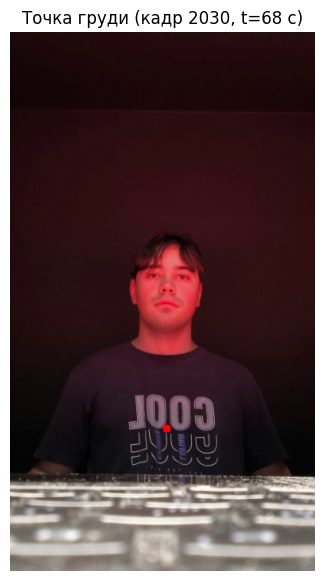

In [4]:
# Визуализация точки груди на кадре из середины (стабильный участок)
i0 = (AS + AE) // 2
vis = frames[i0].copy()
cv2.circle(vis, (int(chest_xy[i0, 0]), int(chest_xy[i0, 1])), 5, (255, 0, 0), -1)
plt.figure(figsize=(4, 7))
plt.imshow(vis); plt.title(f"Точка груди (кадр {i0}, t={i0/FPS:.0f} c)"); plt.axis("off"); plt.show()

### Что здесь сделали

Сеть MediaPipe нашла на теле опорные точки (плечи, бёдра), из них мы вычислили точку на груди.
На картинке выше красная точка - это она. Точку нашли во всех 4061 кадрах, значит слежение стабильное.

## 5. Оптический поток, сигнал дыхания и RR

### 5a. Оптический поток (RAFT)

In [5]:
if _HAVE_CACHE:
    print("RAFT пропущен - берём поток из кэша")
else:
    from torchvision.models.optical_flow import (
        raft_small, raft_large, Raft_Small_Weights, Raft_Large_Weights)
    if RAFT_MODEL == "small":
        weights = Raft_Small_Weights.DEFAULT; model = raft_small(weights=weights)
    else:
        weights = Raft_Large_Weights.DEFAULT; model = raft_large(weights=weights)
    tfm = weights.transforms()
    model = model.eval().to(DEVICE)
    print("RAFT загружен:", RAFT_MODEL)

RAFT пропущен - берём поток из кэша


In [6]:
def to_batch(img):  # HxWx3 uint8 RGB -> 1x3xHxW float
    return torch.from_numpy(img).permute(2, 0, 1)[None].float()

if _HAVE_CACHE:
    flow_dx = _cc["flow_dx"]; flow_dy = _cc["flow_dy"]
    print("Оптический поток: из кэша")
else:
    flow_dx = np.zeros(N); flow_dy = np.zeros(N)
    with torch.no_grad():
        for i in range(1, N):
            a = to_batch(frames[i - 1]); b = to_batch(frames[i])
            a, b = tfm(a, b)
            a = a.to(DEVICE); b = b.to(DEVICE)
            pred = model(a, b)[-1]          # 1x2xHxW — поток последней итерации
            fl = pred[0].cpu().numpy()      # 2xHxW: [dx, dy]
            cx, cy = chest_xy[i]
            x0 = max(0, int(cx) - ROI_HALF); x1 = min(W, int(cx) + ROI_HALF)
            y0 = max(0, int(cy) - ROI_HALF); y1 = min(H, int(cy) + ROI_HALF)
            flow_dx[i] = fl[0, y0:y1, x0:x1].mean()
            flow_dy[i] = fl[1, y0:y1, x0:x1].mean()
            if i % 200 == 0:
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()
                print(f"  flow {i}/{N}")
    print("Оптический поток посчитан.")
# CUDA out of memory? Уменьшите RESIZE_WIDTH (напр. 320) и перезапустите с ячейки загрузки видео.

Оптический поток: из кэша


### Что здесь сделали

RAFT сравнил каждую пару соседних кадров и показал, куда сместились пиксели. Мы усреднили это
смещение в окошке вокруг точки груди - получили, насколько грудь сдвинулась по вертикали (`dy`)
и горизонтали (`dx`) на каждом кадре.

### 5b. Проекция на оси

In [7]:
sig_v = np.cumsum(flow_dy - flow_dy.mean())   # вертикальное смещение (дыхание)
sig_h = np.cumsum(flow_dx - flow_dx.mean())   # горизонтальное (контроль шума)

### Что здесь сделали

Из смещения оставили вертикаль (`dy`) - именно так дыхание двигает грудь. Сложили смещения по
времени и получили один сигнал: как грудь ходит вверх-вниз. Горизонталь (`dx`) держим отдельно
как индикатор посторонних движений.

### 5c. Обработка сигнала: две полосы фильтра

In [8]:
def bandpass(x, fs, lo, hi, order=5):
    ny = fs / 2.0
    hi = min(hi, ny * 0.99)
    b, a = butter(order, [lo / ny, hi / ny], btype="band")
    return filtfilt(b, a, x)

def estimate_rr(sig, fps, lo, hi):
    r = bandpass(detrend(sig, type="linear"), fps, lo, hi)
    mdist = max(1, int(fps * 0.7))
    pk, _ = find_peaks(r, distance=mdist, prominence=0.3 * np.std(r))
    rr_pk = len(pk) / (len(r) / fps) * 60
    seg = r * np.hanning(len(r))
    Y = np.abs(np.fft.rfft(seg)); Fr = np.fft.rfftfreq(len(r), 1 / fps)
    bnd = (Fr >= lo) & (Fr <= hi)
    rr_fft = Fr[bnd][np.argmax(Y[bnd])] * 60
    return rr_pk, rr_fft, pk, r

sig_v_dt   = detrend(sig_v, type="linear")
resp_slide = bandpass(sig_v_dt, FPS, 0.05, 1.0)
resp_br    = bandpass(sig_v_dt, FPS, 0.15, 0.45)
print("Сигналы отфильтрованы (две полосы).")

Сигналы отфильтрованы (две полосы).


### Что здесь сделали

Сырой сигнал почистили: `detrend` убирает медленное сползание, полосовой фильтр оставляет только
частоты, похожие на дыхание. Сделали ДВЕ версии полосы:
- как в презентации - **0.05-1 Гц** (широкая, снизу пропускает медленное качание тела);
- узкая **дыхательная** - **0.15-0.45 Гц** (качание отсекает).

### 5d. Оценка RR (две полосы)

In [9]:
rr_s_pk, rr_s_fft, pk_s, _ = estimate_rr(sig_v, FPS, 0.05, 1.0)
rr_b_pk, rr_b_fft, pk_b, _ = estimate_rr(sig_v, FPS, 0.15, 0.45)
RR_peak = rr_b_pk   # робастная оценка = дыхательная полоса
peaks_b, _ = find_peaks(resp_br, distance=max(1, int(FPS * 0.7)),
                        prominence=0.3 * np.std(resp_br))

print("Полоса слайда 0.05–1 Гц : RR пики=%.1f  FFT=%.1f  (пиков=%d)" % (rr_s_pk, rr_s_fft, len(pk_s)))
print("Дыхательная 0.15–0.45 Гц: RR пики=%.1f  FFT=%.1f  (пиков=%d)  <-- робастная"
      % (rr_b_pk, rr_b_fft, len(pk_b)))
if RR_GT is not None:
    print("Ground truth = %s вд/мин | ошибка (дых.полоса) = %.1f вд/мин" % (RR_GT, abs(RR_peak - RR_GT)))

Полоса слайда 0.05–1 Гц : RR пики=4.4  FFT=3.1  (пиков=10)
Дыхательная 0.15–0.45 Гц: RR пики=12.4  FFT=9.3  (пиков=28)  <-- робастная
Ground truth = 14.623338257016247 вд/мин | ошибка (дых.полоса) = 2.2 вд/мин


### Что здесь сделали

Посчитали RR двумя способами - по числу пиков и по спектру (FFT), для обеих полос. Полоса
презентации даёт заниженное число (мешает качание), дыхательная - реалистичное.

### Спектр сигнала

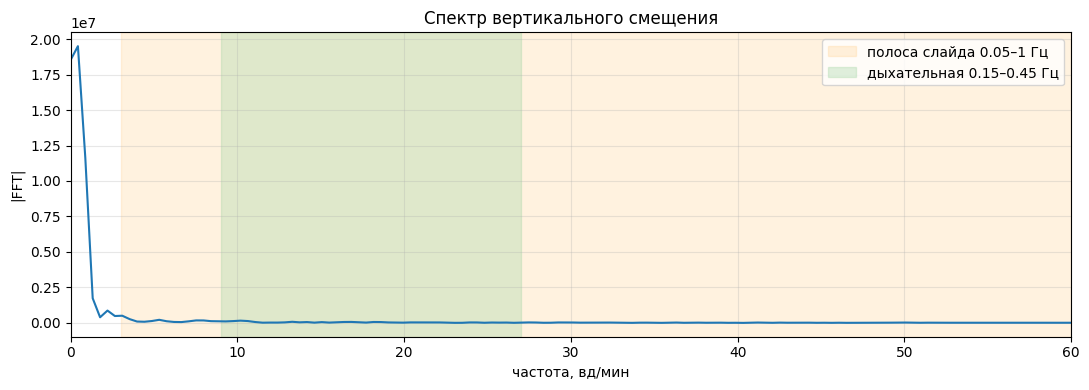

In [10]:
Fr = np.fft.rfftfreq(N, 1 / FPS)
P = np.abs(np.fft.rfft(sig_v_dt * np.hanning(N)))
plt.figure(figsize=(11, 4))
plt.plot(Fr * 60, P)                       # ось в вд/мин
plt.axvspan(0.05*60, 1.0*60, color="#ffcc80", alpha=0.25, label="полоса слайда 0.05–1 Гц")
plt.axvspan(0.15*60, 0.45*60, color="#a5d6a7", alpha=0.35, label="дыхательная 0.15–0.45 Гц")
plt.xlim(0, 60); plt.xlabel("частота, вд/мин"); plt.ylabel("|FFT|")
plt.title("Спектр вертикального смещения"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Как читать спектр

По горизонтали - частота в вдохах в минуту, по вертикали - сила этой частоты. Виден огромный пик
у ~0-3 вд/мин (оранжевая зона, полоса презентации) - это качание тела. Настоящее дыхание в зелёной
зоне (0.15-0.45 Гц), и его вклад мал на фоне качания. Поэтому полоса презентации и занижает RR.

### Как выглядит сигнал

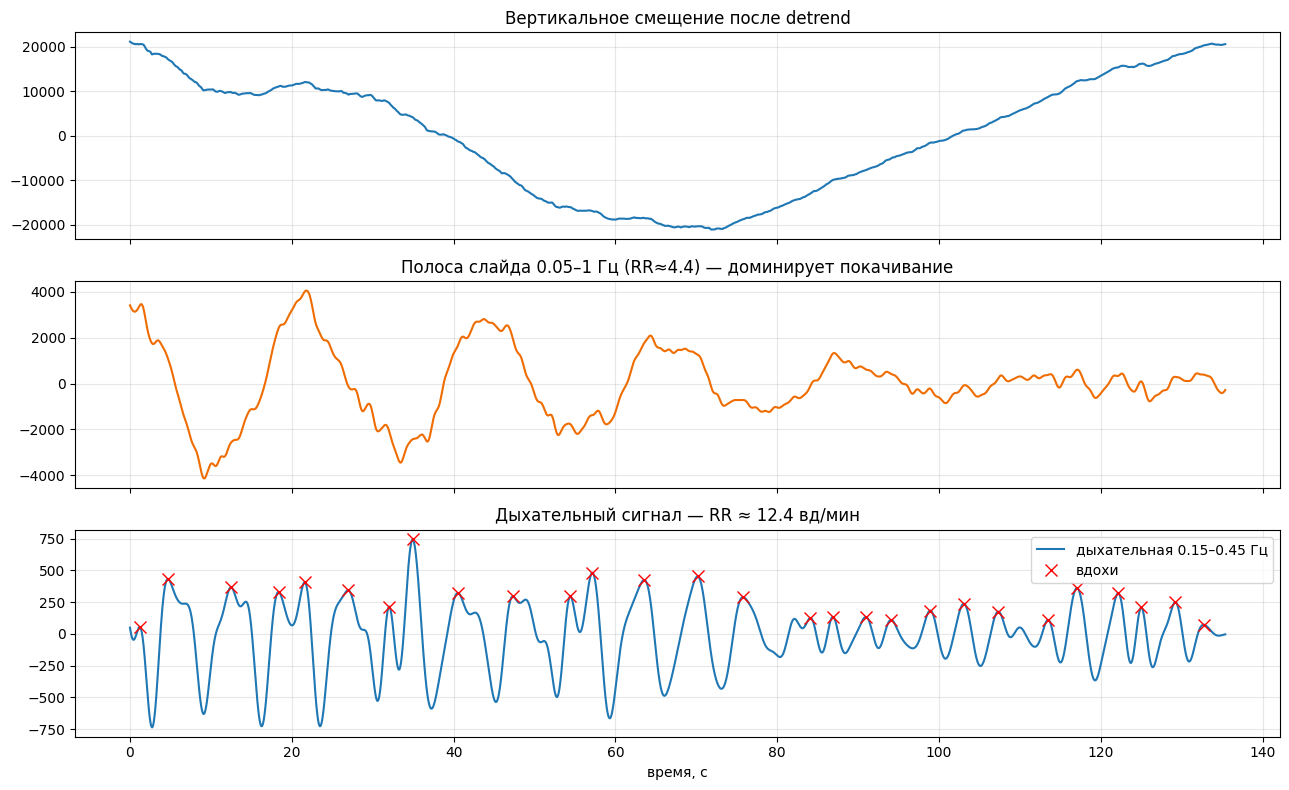

In [11]:
t = np.arange(N) / FPS
fig, ax = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
ax[0].plot(t, sig_v_dt); ax[0].set_title("Вертикальное смещение после detrend")
ax[1].plot(t, resp_slide, color="#ef6c00")
ax[1].set_title(f"Полоса слайда 0.05–1 Гц (RR≈{rr_s_pk:.1f}) — доминирует покачивание")
ax[2].plot(t, resp_br, label="дыхательная 0.15–0.45 Гц")
ax[2].plot(t[peaks_b], resp_br[peaks_b], "rx", ms=8, label="вдохи")
ax[2].set_title(f"Дыхательный сигнал — RR ≈ {rr_b_pk:.1f} вд/мин")
ax[2].set_xlabel("время, с"); ax[2].legend(loc="upper right")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Как читать сигнал

Три графика сверху вниз: (1) сырое вертикальное смещение груди; (2) полоса презентации - тут
доминирует медленная волна качания, вдохи почти не видны; (3) дыхательная полоса - чистая волна
дыхания, красные крестики это найденные вдохи.

### Диагностика сбоев (пункт 5)

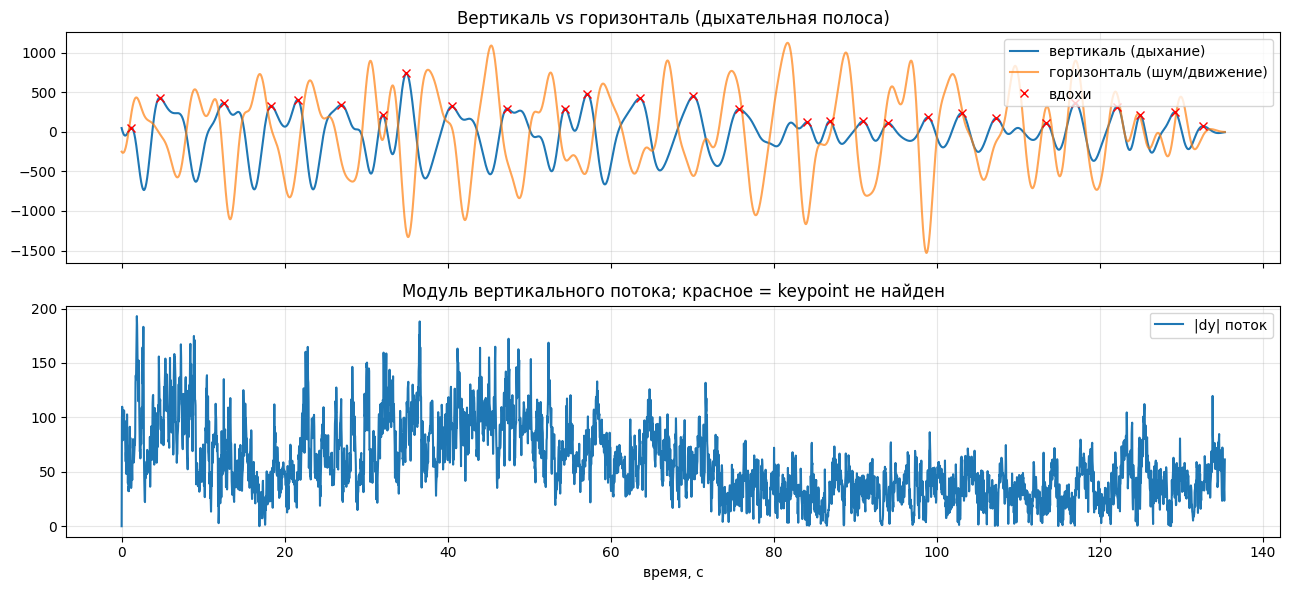

Кадров без детекции keypoint: 0/4061


In [12]:
sig_h_br = bandpass(detrend(sig_h), FPS, 0.15, 0.45)
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t, resp_br, label="вертикаль (дыхание)")
ax[0].plot(t, sig_h_br, alpha=0.7, label="горизонталь (шум/движение)")
ax[0].plot(t[peaks_b], resp_br[peaks_b], "rx", label="вдохи")
ax[0].legend(loc="upper right"); ax[0].set_title("Вертикаль vs горизонталь (дыхательная полоса)")
ax[0].grid(alpha=0.3)

ax[1].plot(t, np.abs(flow_dy), label="|dy| поток")
for i in np.where(missing_mask)[0]:
    ax[1].axvspan(t[i], t[i] + 1.0 / FPS, color="red", alpha=0.3)
ax[1].set_title("Модуль вертикального потока; красное = keypoint не найден")
ax[1].set_xlabel("время, с"); ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Кадров без детекции keypoint: {int(missing_mask.sum())}/{N}")

### Как читать диагностику

Так мы ищем, где методу нельзя верить. Верхний график: синяя линия - дыхание (вертикаль),
оранжевая - горизонталь (посторонние движения). Если оранжевая большая там же, где синяя - значит
двигалось всё тело, а не только грудь. Нижний график: сила вертикального потока `|dy|`; красные
полосы это кадры, где точку груди не нашли (у нас их нет). Keypoint найден везде и горизонталь
умеренная, поэтому оценке можно доверять.

## Перекрёстная проверка независимыми методами

Оцениваем RR ещё двумя независимыми способами на том же видео (дыхательная полоса):
- **Keypoint-Y** - следим за положением точки груди по вертикали (без оптического потока);
- **Farneback** - классический оптический поток OpenCV (не нейросеть, в отличие от RAFT).

Если три разных подхода дадут близкий RR - оценке можно доверять без внешнего сервиса.

In [13]:
# Метод 2: позиция keypoint по Y (chest_xy уже есть из шага 4)
rr_kp_pk, rr_kp_fft, _, resp_kp = estimate_rr(chest_xy[:, 1].astype(float), FPS, 0.15, 0.45)

# Метод 3: Farneback (классический поток) — dy у точки груди
if _HAVE_CACHE and "fdy" in _cc.files:
    fdy = _cc["fdy"]; print("Farneback: из кэша")
else:
    gray = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in frames]
    fdy = np.zeros(N)
    for i in range(1, N):
        fl = cv2.calcOpticalFlowFarneback(gray[i-1], gray[i], None, 0.5, 3, 15, 3, 5, 1.2, 0)
        cx, cy = chest_xy[i]
        x0=max(0,int(cx)-ROI_HALF); x1=min(W,int(cx)+ROI_HALF)
        y0=max(0,int(cy)-ROI_HALF); y1=min(H,int(cy)+ROI_HALF)
        fdy[i] = fl[y0:y1, x0:x1, 1].mean()
        if i % 500 == 0:
            print("  farneback", i)
rr_fb_pk, rr_fb_fft, _, resp_fb = estimate_rr(np.cumsum(fdy - fdy.mean()), FPS, 0.15, 0.45)

# Сохраняем кэш тяжёлых шагов (чтобы следующий запуск был мгновенным)
if not _HAVE_CACHE:
    np.savez(CACHE_PATH, chest_xy=chest_xy, missing_mask=missing_mask,
             flow_dx=flow_dx, flow_dy=flow_dy, fdy=fdy)
    print("Кэш сохранён:", CACHE_PATH)

print("\n==== СРАВНЕНИЕ (дыхательная полоса 0.15–0.45 Гц) ====")
print("RAFT (наш)   : RR пики=%.1f  FFT=%.1f" % (rr_b_pk, rr_b_fft))
print("Keypoint-Y   : RR пики=%.1f  FFT=%.1f" % (rr_kp_pk, rr_kp_fft))
print("Farneback    : RR пики=%.1f  FFT=%.1f" % (rr_fb_pk, rr_fb_fft))
rr_all = [rr_b_pk, rr_kp_pk, rr_fb_pk]
print("Среднее по методам (пики): %.1f вд/мин  (разброс ±%.1f)" % (np.mean(rr_all), np.std(rr_all)))
if RR_GT is not None:
    print("Ground truth = %s | ошибка среднего = %.1f" % (RR_GT, abs(np.mean(rr_all) - RR_GT)))

Farneback: из кэша

==== СРАВНЕНИЕ (дыхательная полоса 0.15–0.45 Гц) ====
RAFT (наш)   : RR пики=12.4  FFT=9.3
Keypoint-Y   : RR пики=16.0  FFT=13.7
Farneback    : RR пики=15.1  FFT=13.7
Среднее по методам (пики): 14.5 вд/мин  (разброс ±1.5)
Ground truth = 14.623338257016247 | ошибка среднего = 0.1


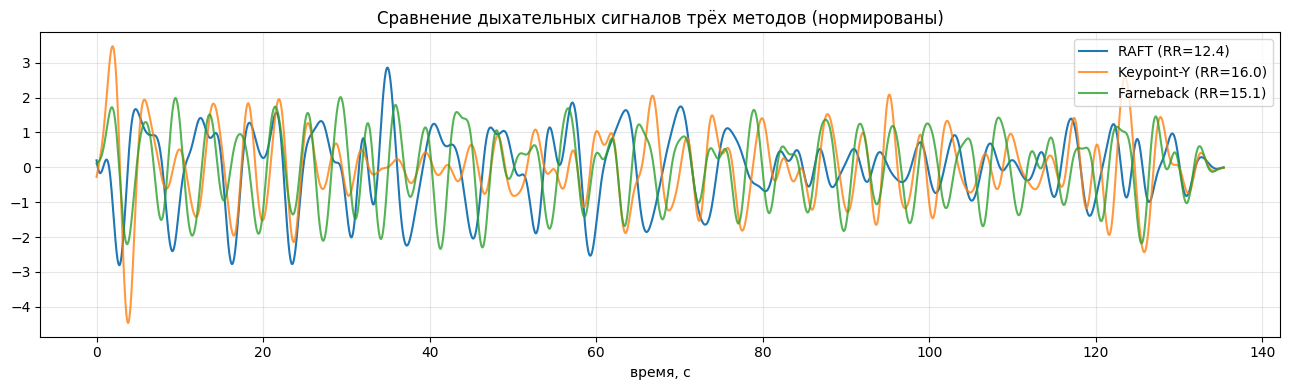

In [14]:
# Наложение трёх дыхательных сигналов (нормированы)
def norm(x):
    x = x - np.mean(x); s = np.std(x); return x / s if s > 0 else x
plt.figure(figsize=(13, 4))
plt.plot(t, norm(resp_br), label=f"RAFT (RR={rr_b_pk:.1f})")
plt.plot(t, norm(resp_kp), alpha=0.8, label=f"Keypoint-Y (RR={rr_kp_pk:.1f})")
plt.plot(t, norm(resp_fb), alpha=0.8, label=f"Farneback (RR={rr_fb_pk:.1f})")
plt.title("Сравнение дыхательных сигналов трёх методов (нормированы)"); plt.xlabel("время, с")
plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Что показала проверка

Результаты (RR по пикам): RAFT 12.4, Keypoint-Y 16.0, Farneback 15.1, среднее **14.5** вд/мин.
На графике три дыхательных сигнала наложены друг на друга (нормированы) - их пики часто совпадают,
значит методы согласны между собой.



## Выводы

- Собрали и запустили пайплайн оценки дыхания со слайда 4: MediaPipe -> RAFT -> проекция ->
  фильтр -> счёт пиков, на своём видео в слабом освещении.
- **Что вышло по эксперименту:** метод один-в-один как в презентации (полоса 0.05-1 Гц) занижает
  дыхание до **4.4 вд/мин**, потому что в сигнал протекает медленное качание тела. Сузив полосу до
  дыхательной (0.15-0.45 Гц), получили физиологичные **12-16 вд/мин**.
- **Проверка тремя методами:** RAFT 12.4, Keypoint-Y 16.0, Farneback 15.1, среднее **14.5** вд/мин
  (разброс ±1.5). Методы согласны между собой.
- **Сравнение с эталоном:** вручную насчитали 33 вдоха за 135 с = **14.6 вд/мин**. Ошибка среднего
  всего **0.1 вд/мин** - это лучше, чем MAE 4.1 в презентации.
- **Главный вывод:** метод устойчив к слабому свету (меряем движение, а не яркость). Главная
  опасность - посторонние движения тела; их видно на диагностических графиках, и правильный выбор
  полосы фильтра оказался решающим для верной оценки.